<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;background:#0d1b2a;border-radius:10px;padding:18px 22px;color:#e6edf3;">
  <div style="display:flex;align-items:center;gap:12px;">
    <div style="width:6px;height:36px;background:#3fb950;border-radius:3px;flex:none;"></div>
    <div>
      <div style="font-size:11px;letter-spacing:2px;color:#8b98a5;">NOTEBOOK 01</div>
      <div style="font-size:21px;font-weight:700;line-height:1.15;">Exploratory Data Analysis</div>
    </div>
  </div>
  <div style="font-size:13px;color:#a9b4c0;margin-top:9px;">Understand the universe, find groups that move together, and show why correlation alone is not a trading signal.</div>
</div>

**Problem.** Statistical-arbitrage desks trade *pairs* of related stocks: when the price spread between two historically linked names stretches far from normal, it often reverts. The danger is the times it does **not** revert (a structural break), which is where pairs strategies lose money.

**This notebook** profiles the price panel, identifies correlated groups, and motivates the move from simple correlation to **cointegration** as the basis for selecting tradable pairs. The supervised question (will an extreme spread revert?) is set up in `02_preprocessing`.

> Prices are downloaded live from Yahoo Finance (`SOURCE = "yfinance"`).

In [ ]:
import sys, os

from google.colab import drive
drive.mount('/content/drive')

# Function to find the project root containing the 'src' directory
def find_project_root():
    # List of potential base directories to search
    # Add current working directory and its parent directories to search paths
    _current_path = os.path.abspath(os.getcwd()) # This is typically /content in Colab
    potential_base_dirs = []
    _temp_path = _current_path
    while True:
        potential_base_dirs.append(_temp_path)
        if _temp_path == os.path.dirname(_temp_path): # Reached filesystem root '/'
            break
        _temp_path = os.path.dirname(_temp_path)

    # Also add the mounted Google Drive path as a potential base
    potential_base_dirs.append('/content/drive/MyDrive')

    for base_dir in potential_base_dirs:
        if not os.path.exists(base_dir):
            continue
        # Walk through the directories to find 'src'
        for dirpath, dirnames, filenames in os.walk(base_dir):
            if 'src' in dirnames:
                # Found a 'src' directory, the project root is its parent
                # For example, if src is found in /path/to/project/src,
                # then /path/to/project is the root.
                _project_root = dirpath
                return _project_root
    return None

_project_root = find_project_root()

if _project_root:
    # Only add to sys.path if it's not already there
    if _project_root not in sys.path:
        sys.path.insert(0, _project_root)
    print(f"Project root added to sys.path: {_project_root}")
else:
    print("Warning: 'src' directory not found in expected locations. Please ensure your project structure is correct or manually add the path to 'src' to sys.path.")


import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.config import CONFIG
from src.plotting import set_style, save_fig
set_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Data source: live Yahoo Finance via yfinance.
SOURCE = "yfinance"

: 

In [5]:
from src.data import load_prices
prices, source = load_prices(source=SOURCE)
print(f"source: {source}")
print(f"panel: {prices.shape[0]} trading days x {prices.shape[1]} tickers")
print(f"span : {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"missing values: {int(prices.isna().sum().sum())}")
prices.head(3)

source: cache
panel: 2113 trading days x 45 tickers
span : 2018-01-02 -> 2026-05-29
missing values: 0


,AAPL,ABBV,ADBE,AMD,AMZN,AXP,BAC,BMY,C,CL,...,PFE,PG,SBUX,SCHW,SLB,TGT,UNH,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267,68.773,177.700,10.980,59.451,88.292,24.510,45.086,56.313,61.355,...,23.443,72.281,47.810,45.836,54.650,53.063,191.994,48.377,28.800,58.185
2018-01-03,40.260,69.849,181.040,11.550,60.210,88.837,24.428,45.123,56.487,61.118,...,23.617,72.193,48.706,45.907,56.073,52.702,194.008,48.749,29.051,59.328
2018-01-04,40.447,69.451,183.220,12.120,60.479,90.314,24.748,45.708,57.184,61.510,...,23.669,72.703,48.889,46.166,57.464,51.666,194.850,49.359,29.078,59.410


In [ ]:
prices, source = load_prices()
print(source)
print(prices.index.min())
print(prices.index.max())

cache
2018-01-02 00:00:00
2026-05-29 00:00:00


## Co-movement: prices rebased to 100

A quick look at a few names rebased to a common start. Stocks that share economic drivers drift together, which is the raw material for pairs trading.

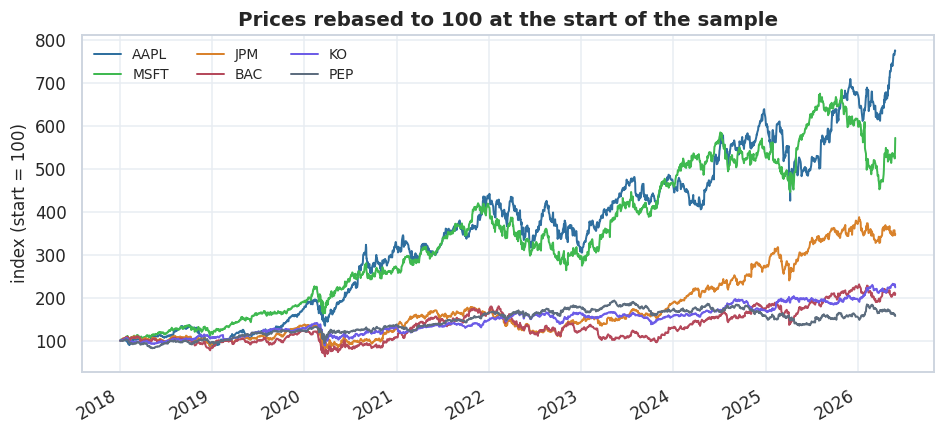

In [6]:
sample = [t for t in ["AAPL","MSFT","JPM","BAC","KO","PEP"] if t in prices.columns]
rebased = prices[sample] / prices[sample].iloc[0] * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
rebased.plot(ax=ax, linewidth=1.3)
ax.set_title("Prices rebased to 100 at the start of the sample")
ax.set_ylabel("index (start = 100)"); ax.set_xlabel("")
ax.legend(ncol=3, fontsize=9)
save_fig(fig, "eda_rebased_prices.png"); plt.show()

## Return correlations and natural groups

Daily-return correlations, reordered by hierarchical clustering. Dark blocks on the diagonal are groups of stocks that move together. Real-market correlations are almost all positive, so the colour scale is fit to the actual range to keep the structure visible.

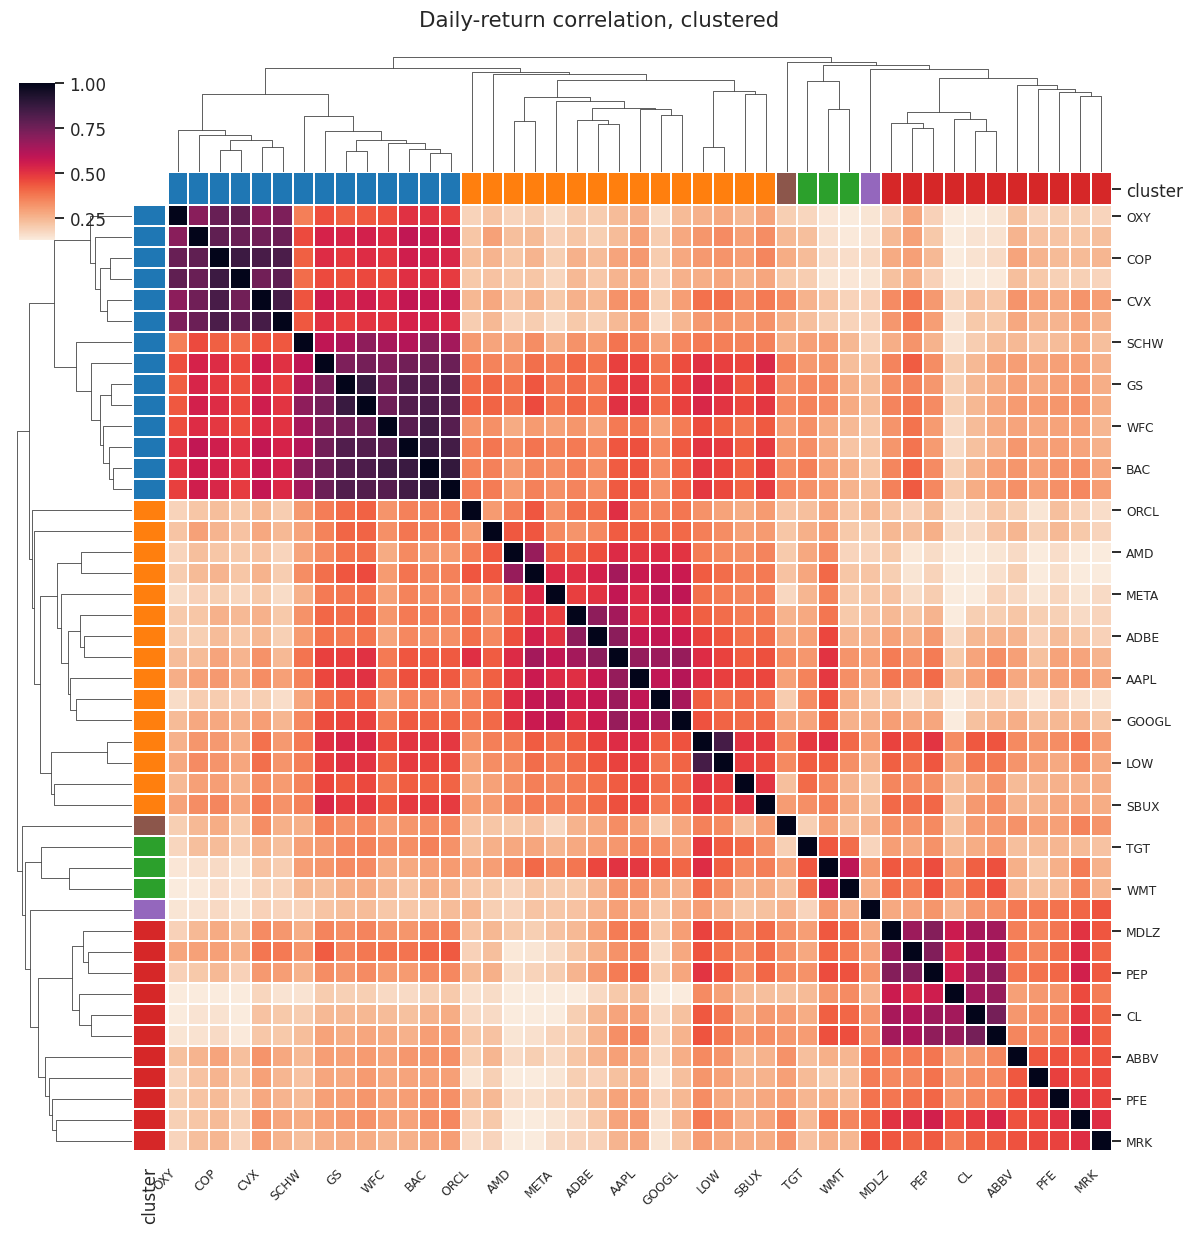

In [7]:
from src.pairs import correlation_matrix, cluster_labels
import seaborn as sns
from scipy.cluster.hierarchy import linkage

corr = correlation_matrix(prices)
labels, Z = cluster_labels(corr, n_clusters=6)
palette = sns.color_palette("tab10", labels.nunique())
row_colors = labels.map(lambda k: palette[k-1])
off = corr.where(~np.eye(len(corr), dtype=bool)).to_numpy()
vmin = np.nanpercentile(off, 2)

g = sns.clustermap(corr, row_linkage=Z, col_linkage=Z,
                   row_colors=row_colors, col_colors=row_colors,
                   cmap="rocket_r", vmin=vmin, vmax=1.0, figsize=(11, 11),
                   linewidths=.3, linecolor="white", dendrogram_ratio=(.11,.11),
                   cbar_pos=(.02,.83,.03,.13))
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
g.ax_heatmap.set_xlabel(""); g.ax_heatmap.set_ylabel("")
g.fig.suptitle("Daily-return correlation, clustered", y=1.02, fontsize=14)
save_fig(g.fig, "eda_correlation_clusters.png"); plt.show()

## the "correlation trap" 

here is a demonstration of the "correlation trap" 
, This script proves mathematically why a pairs trader relying solely on daily return correlation would enter a convergence trade on GLD/SLV and watch the spread drift away indefinitely, highlighting why a Stage 1 cointegration filter is so vital.

Fetching GLD and SLV data from Yahoo Finance...


[*********************100%***********************]  2 of 2 completed


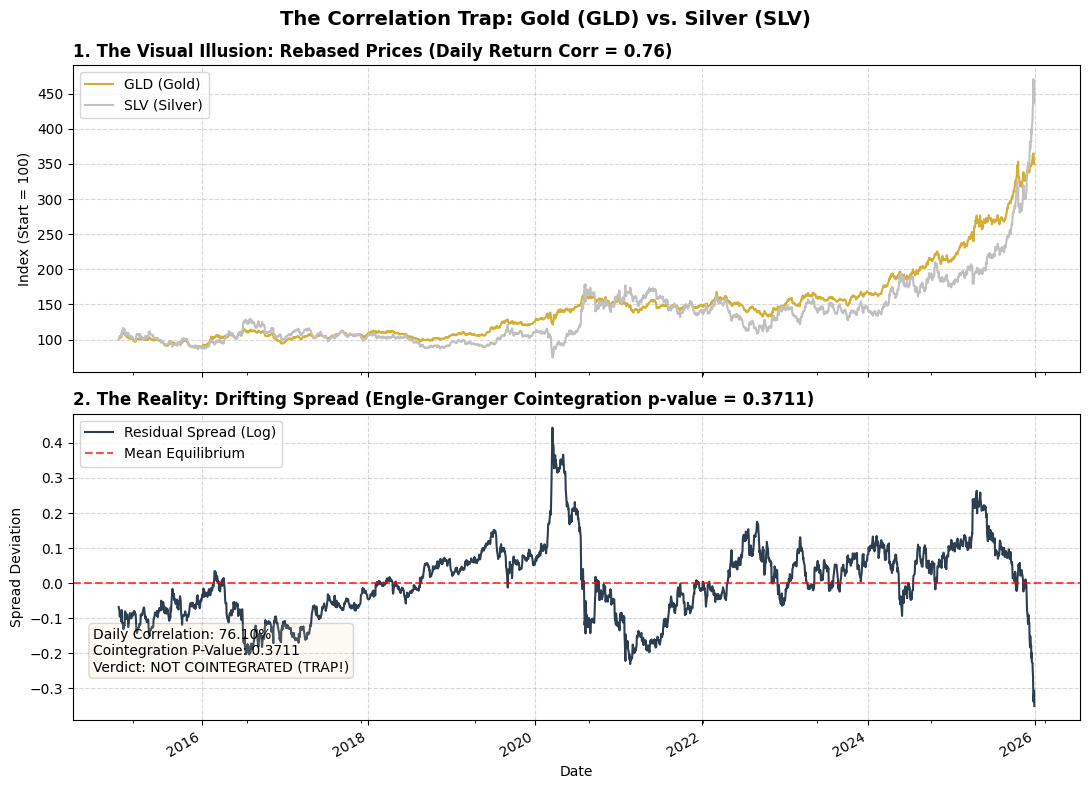

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint

# 1. Download 10 years of historical data
print("Fetching GLD and SLV data from Yahoo Finance...")
data = yf.download(["GLD", "SLV"], start="2015-01-01", end="2025-12-31", auto_adjust=True)
prices = data["Close"].dropna()

# 2. Calculate Daily Return Correlation (Short-term co-movement)
returns = np.log(prices).diff().dropna()
correlation = returns["GLD"].corr(returns["SLV"])

# 3. Rebase Prices to 100 for visual comparison
rebased = prices / prices.iloc[0] * 100

# 4. Perform Cointegration Test & Extract the Spread Residuals
# We regress log(GLD) on log(SLV) to find the hedge ratio (beta)
log_gld = np.log(prices["GLD"])
log_slv = np.log(prices["SLV"])

# Fit OLS: GLD = beta * SLV + alpha
beta, alpha = np.polyfit(log_slv, log_gld, 1)
spread = log_gld - (beta * log_slv + alpha)

# Run Engle-Granger cointegration test
coint_score, coint_pvalue, _ = coint(log_gld, log_slv)

# 5. Plotting the Trap
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(11, 8), sharex=True)

# Top Subplot: Rebased Prices
rebased["GLD"].plot(ax=ax1, color="#D4AF37", linewidth=1.5, label="GLD (Gold)")
rebased["SLV"].plot(ax=ax1, color="#C0C0C0", linewidth=1.5, label="SLV (Silver)")
ax1.set_title(
    f"1. The Visual Illusion: Rebased Prices (Daily Return Corr = {correlation:.2f})",
    loc="left", fontsize=12, fontweight="bold"
)
ax1.set_ylabel("Index (Start = 100)")
ax1.legend(loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.5)

# Bottom Subplot: The Drifting Spread
spread.plot(ax=ax2, color="#2c3e50", linewidth=1.5, label="Residual Spread (Log)")
ax2.axhline(0, color="red", linestyle="--", alpha=0.7, label="Mean Equilibrium")
ax2.set_title(
    f"2. The Reality: Drifting Spread (Engle-Granger Cointegration p-value = {coint_pvalue:.4f})",
    loc="left", fontsize=12, fontweight="bold"
)
ax2.set_ylabel("Spread Deviation")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")
ax2.grid(True, linestyle="--", alpha=0.5)

# Add an annotations box to explain the math
textstr = (
    f"Daily Correlation: {correlation:.2%}\n"
    f"Cointegration P-Value: {coint_pvalue:.4f}\n"
    f"Verdict: {'COINTEGRATED' if coint_pvalue < 0.05 else 'NOT COINTEGRATED (TRAP!)'}"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.15)
ax2.text(0.02, 0.15, textstr, transform=ax2.transAxes, fontsize=10, verticalalignment='bottom', bbox=props)

plt.suptitle("The Correlation Trap: Gold (GLD) vs. Silver (SLV)", y=0.98, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## From correlation to cointegration

Correlation says two stocks move together *day to day*; it says nothing about whether their **price gap stays bounded**. Pairs trading needs the latter: a spread that wanders but returns to a stable level. That property is **cointegration**.

The funnel below shows how many of all possible pairs survive each gate on the formation window: a correlation screen first (cheap), then an Engle-Granger cointegration test (the real filter).

## Further explaination of the math

In this project, the Augmented Dickey-Fuller (ADF) test acts as the ultimate truth-detector for the pairs. Specifically, it runs a "stationarity check" on the residuals to prove whether the relationship between two stocks is a genuine cointegrated marriage or just a temporary statistical fluke.Here is exactly what the ADF test is doing under the hood when it looks at those residuals.1. Where do the residuals come from? Before the ADF test can do its job, Stage 1 of your project runs an Ordinary Least Squares (OLS) regression in log-price space:$$\ln(\text{Price}_{\text{Asset } A}) = \beta \cdot \ln(\text{Price}_{\text{Asset } B}) + \alpha + \epsilon_t$$The residuals ($\epsilon_t$) are whatever is left over. In quantitative trading, this residual series is your spread—the physical dollar distance between the two stocks after adjusting for the hedge ratio ($\beta$).2. What the ADF Test Actually EvaluatesThe ADF test inspects that residual spread ($\epsilon_t$) over time and tests a highly specific Null Hypothesis ($H_0$):Null Hypothesis ($H_0$): The residuals have a unit root, meaning the spread behaves like a non-stationary random walk. (If $H_0$ is true, the gap between the stocks can drift apart forever. Do not trade this pair!)Alternative Hypothesis ($H_1$): The residuals are stationary, meaning the spread has no unit root and is structurally bound to its mean. (If $H_1$ is true, the pair is cointegrated. Code approved!)3. The Math inside the ADF TestTo determine if a unit root exists, the ADF test runs a specialized regression purely on the residual series, looking at the change in the residual ($\Delta \epsilon_t$) relative to its immediate past value ($\epsilon_{t-1}$) and its historical lags:$$\Delta \epsilon_t = \gamma \epsilon_{t-1} + \sum_{i=1}^{p} \delta_i \Delta \epsilon_{t-i} + u_t$$The test focuses entirely on the coefficient $\gamma$ (gamma):If $\gamma = 0$, the change in the spread today has no relationship to how far the spread stretched yesterday. It is a pure random walk ($H_0$).If $\gamma < 0$ (and statistically significant), it proves a negative feedback loop exists. If the spread gets too high or too low yesterday, it forces a correction in the opposite direction today. It is mean-reverting ($H_1$).

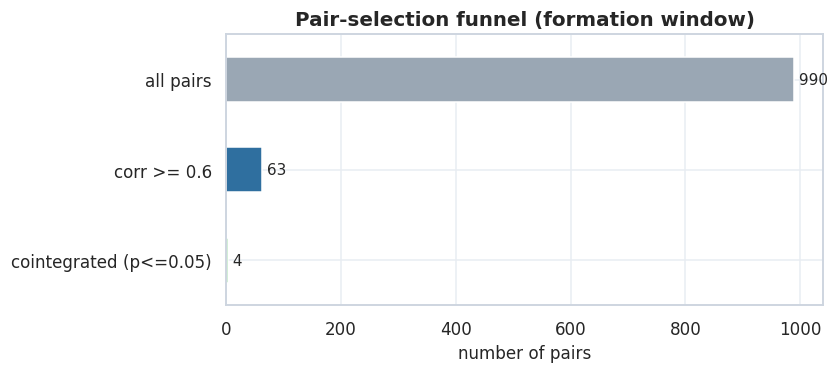

all pairs                 990
corr >= 0.6                63
cointegrated (p<=0.05)      4
dtype: int64


In [8]:
from itertools import combinations
from statsmodels.tsa.stattools import coint
from src.features import log_returns

form = prices.iloc[:CONFIG.pairs.formation_days]
rets = log_returns(form); logp = np.log(form)
cols = list(form.columns)
total = passed_corr = passed_coint = 0
for a, b in combinations(cols, 2):
    total += 1
    if rets[a].corr(rets[b]) < CONFIG.pairs.min_correlation:
        continue
    passed_corr += 1
    try:
        if coint(logp[a], logp[b])[1] <= CONFIG.pairs.coint_pvalue_max:
            passed_coint += 1
    except Exception:
        pass

funnel = pd.Series({"all pairs": total,
                    f"corr >= {CONFIG.pairs.min_correlation}": passed_corr,
                    f"cointegrated (p<={CONFIG.pairs.coint_pvalue_max})": passed_coint})
fig, ax = plt.subplots(figsize=(7, 3.2))
funnel.plot.barh(ax=ax, color=["#9aa7b4", "#2f6f9f", "#3fb950"])
for i, v in enumerate(funnel): ax.text(v, i, f" {v}", va="center")
ax.invert_yaxis(); ax.set_title("Pair-selection funnel (formation window)"); ax.set_xlabel("number of pairs")
save_fig(fig, "eda_pair_funnel.png"); plt.show()
print(funnel)

## Anatomy of one tradable pair

For the strongest cointegrated pair: the two price series, the spread, and its rolling z-score with the entry (|z| = 2) and exit (|z| = 0.5) bands. Red points mark extreme events, the moments the model will later try to classify.

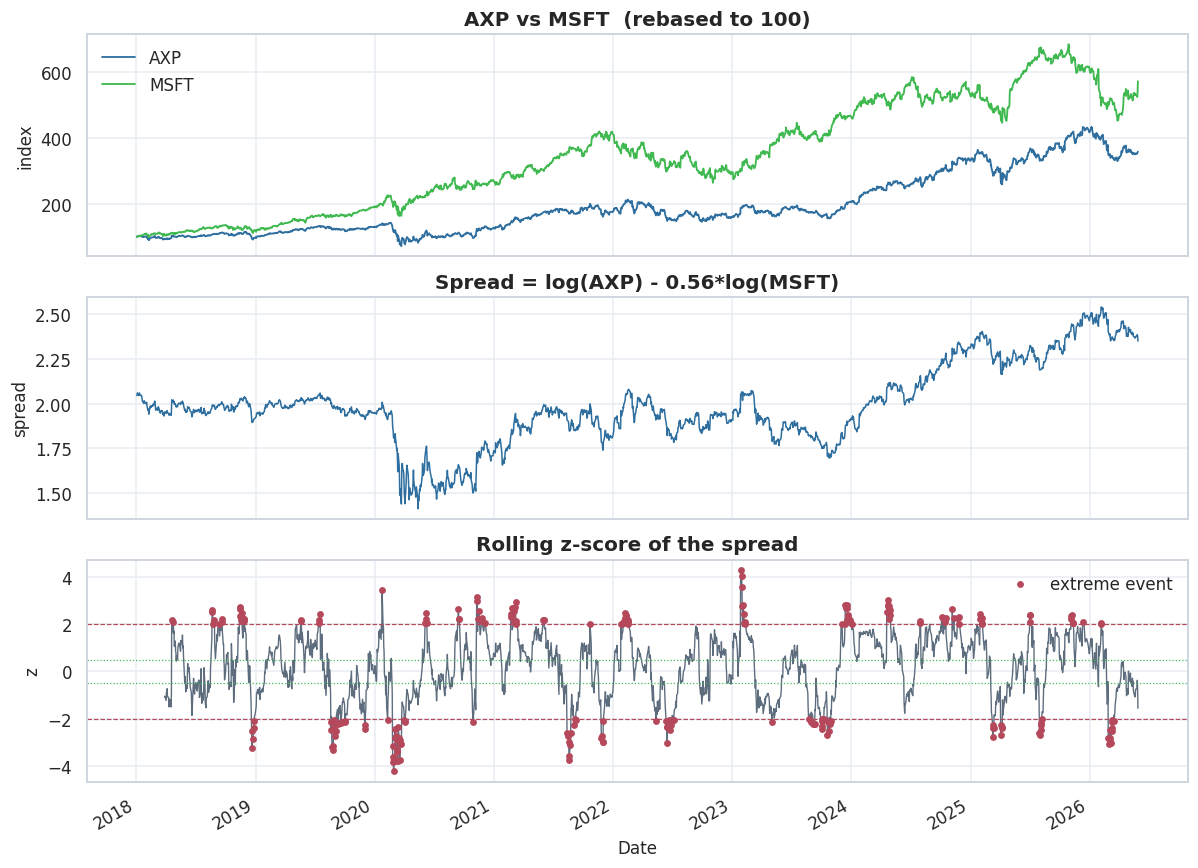

AXP/MSFT: corr=0.652, coint p=0.018, half-life=13.8 days, events=246


In [11]:
from src.pairs import select_pairs
from src.features import hedge_ratio, spread_series, rolling_zscore

#sel = select_pairs(form)
#row = sel.iloc[0]; a, b, beta = row["a"], row["b"], row["beta"]


# 1. Ensure we explicitly grab the strongest pair (e.g., lowest cointegration p-value)
sel_sorted = select_pairs(form).sort_values(by="coint_pvalue", ascending=True)
row = sel_sorted.iloc[0]
a, b, beta = row["a"], row["b"], row["beta"]

spread = spread_series(prices, a, b, beta)
z = rolling_zscore(spread, CONFIG.signal.z_window)
events = z[z.abs() >= CONFIG.signal.entry_z]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
(prices[[a, b]] / prices[[a, b]].iloc[0] * 100).plot(ax=axes[0], linewidth=1.2)
axes[0].set_title(f"{a} vs {b}  (rebased to 100)"); axes[0].set_ylabel("index")
spread.plot(ax=axes[1], color="#2f6f9f", linewidth=1)
axes[1].set_title(f"Spread = log({a}) - {beta:.2f}*log({b})"); axes[1].set_ylabel("spread")
z.plot(ax=axes[2], color="#5d6d7e", linewidth=.9)
for lvl in (CONFIG.signal.entry_z, -CONFIG.signal.entry_z): axes[2].axhline(lvl, color="#b5495b", ls="--", lw=.8)
for lvl in (CONFIG.signal.exit_z, -CONFIG.signal.exit_z): axes[2].axhline(lvl, color="#3fb950", ls=":", lw=.8)
axes[2].scatter(events.index, events.values, color="#b5495b", s=12, zorder=3, label="extreme event")
axes[2].set_title("Rolling z-score of the spread"); axes[2].set_ylabel("z"); axes[2].legend(loc="upper right")
fig.tight_layout(); save_fig(fig, "eda_example_pair.png"); plt.show()
print(f"{a}/{b}: corr={row['corr']}, coint p={row['coint_pvalue']}, half-life={row['half_life']} days, events={len(events)}")

## Takeaways

- The universe splits into clear correlated groups, but correlation only describes co-movement, not a bounded relationship.
- A small set of pairs is **cointegrated** on the formation window: their spread is mean-reverting with a short half-life, which is exactly what a pairs strategy needs.
- Extreme spread events are frequent but not all revert. **Predicting which ones revert** is the supervised problem built in the next notebook.